In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and EDA

In [2]:
df = pd.read_csv(r'C:\\Users\\indra\\Desktop\\GitHub\\AI Appliction\\final_merged_data.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4342 entries, 0 to 4341
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country_x      4342 non-null   str    
 1   ISO3           4342 non-null   str    
 2   Year           4342 non-null   int64  
 3   GHG_Emissions  4342 non-null   float64
 4   GDP_USD        4305 non-null   float64
 5   Country_y      4342 non-null   str    
 6   Unit           4342 non-null   str    
 7   Population     4342 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 271.5 KB


In [4]:
print(df.shape)
print(df["ISO3"].nunique())
print(df["Year"].nunique())

(4342, 8)
167
26


In [5]:
df= df[df['Year'] >= 1999]
df.reset_index(drop=True, inplace=True)

In [6]:
missing_by_country_gdp = (
    df[df['GDP_USD'].isna()]
    .groupby('Country_x').size()
    .sort_values(ascending=False)
)

In [7]:
missing_by_country_gdp.head(15)

Country_x
Eritrea                     13
Cayman Islands               8
Cuba                         4
Afghanistan                  2
Turks and Caicos Islands     2
Syrian Arab Republic         2
Bhutan                       1
Greenland                    1
Palau                        1
Lebanon                      1
Tonga                        1
Tuvalu                       1
dtype: int64

Text(0.5, 0, 'Country_x')

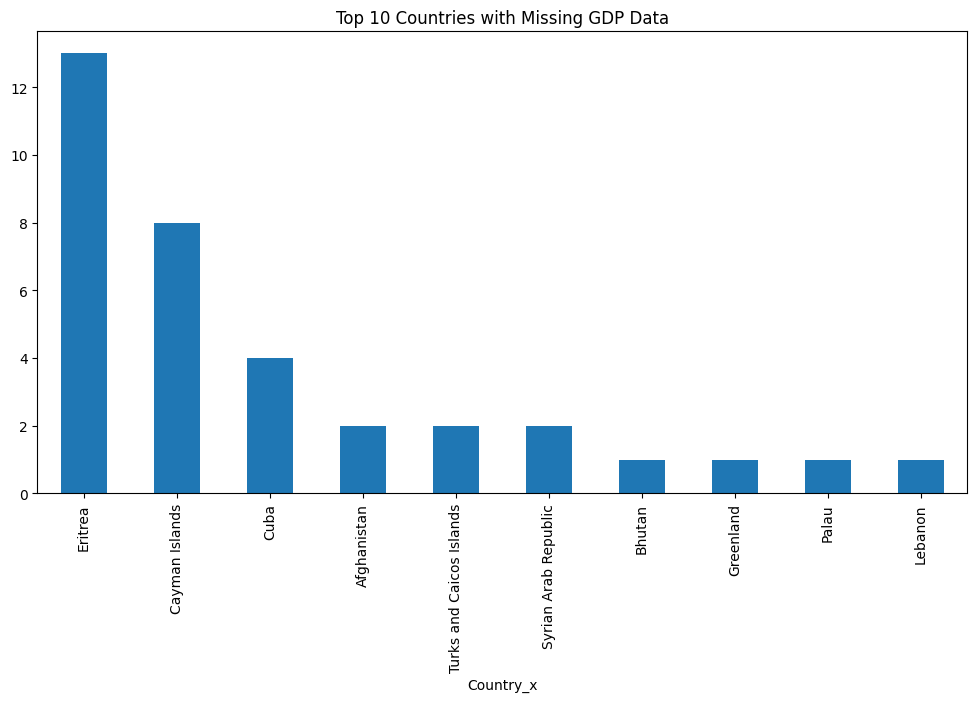

In [8]:
plt.figure(figsize=(12, 6))
missing_by_country_gdp.head(10).plot(kind='bar')
plt.title('Top 10 Countries with Missing GDP Data')
plt.xlabel('Country_x')

### No missing values were found in GHG and Population columns while the GDP columnd had some missing values from smaller countries which are not needed for the analysis.

In [9]:
df.shape
df["ISO3"].nunique()
df["Year"].min(), df["Year"].max()

(np.int64(1999), np.int64(2024))

In [10]:

df['Population'] = pd.to_numeric(df['Population'], errors='coerce')


## Feature Engineering

In [11]:
df['GDPperCapita'] = df['GDP_USD'] / df['Population']
df['GHGperCapita'] = df['GHG_Emissions'] / df['Population']
df['Emission_Intensity'] = df['GHG_Emissions'] / df['GDP_USD']
df.head()

,Country_x,ISO3,Year,GHG_Emissions,GDP_USD,Country_y,Unit,Population,GDPperCapita,GHGperCapita,Emission_Intensity
0,Afghanistan,AFG,1999,16508.477865,NaN,Afghanistan,Persons,19887785.0,NaN,0.000830,NaN
1,Afghanistan,AFG,2000,14364.940472,3.521418e+09,Afghanistan,Persons,20130327.0,174.930991,0.000714,0.000004
2,Afghanistan,AFG,2001,12628.446200,2.813572e+09,Afghanistan,Persons,20284307.0,138.706822,0.000623,0.000004
3,Afghanistan,AFG,2002,15228.571950,3.825701e+09,Afghanistan,Persons,21378117.0,178.954088,0.000712,0.000004
4,Afghanistan,AFG,2003,15857.564957,4.520947e+09,Afghanistan,Persons,22733049.0,198.871116,0.000698,0.000004


## Distribution

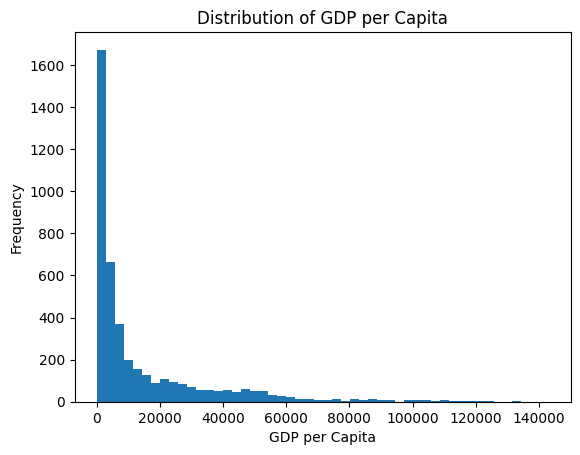

In [12]:
plt.hist(df["GDPperCapita"].dropna(), bins=50)
plt.xlabel("GDP per Capita")
plt.ylabel("Frequency")
plt.title("Distribution of GDP per Capita")
plt.show()

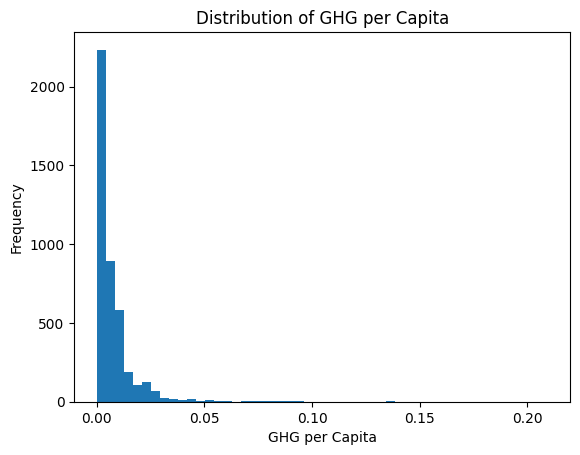

In [13]:
plt.hist(df["GHGperCapita"].dropna(), bins=50)
plt.xlabel("GHG per Capita")
plt.ylabel("Frequency")
plt.title("Distribution of GHG per Capita")
plt.show()

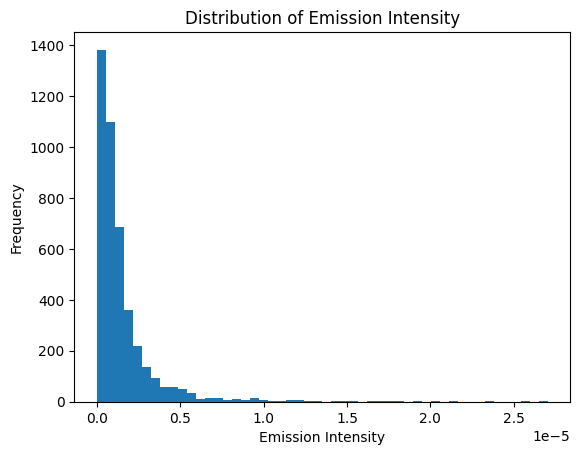

In [14]:
plt.hist(df["Emission_Intensity"].dropna(), bins=50)
plt.xlabel("Emission Intensity")
plt.ylabel("Frequency")
plt.title("Distribution of Emission Intensity")
plt.show()

### GDP/capita, GHG/capita and Emission intensity features were created and visualised. It was found that all three of them were skewed. To reduce the skewness we will crate new lograthmic features for our analysis. 

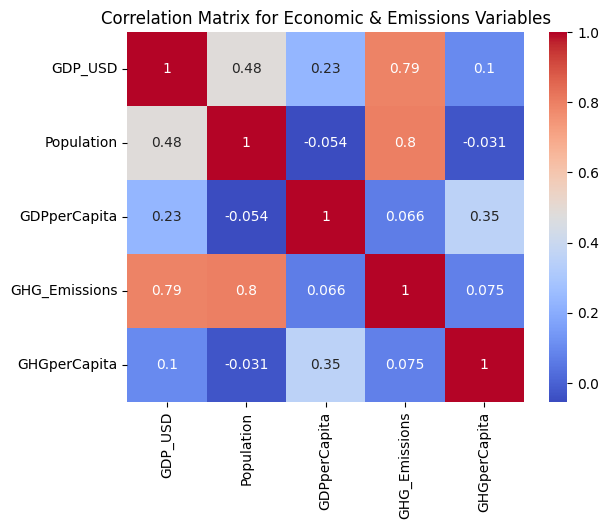

In [15]:
cols = ["GDP_USD", "Population", "GDPperCapita", "GHG_Emissions", "GHGperCapita"]

corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix for Economic & Emissions Variables")
plt.show()

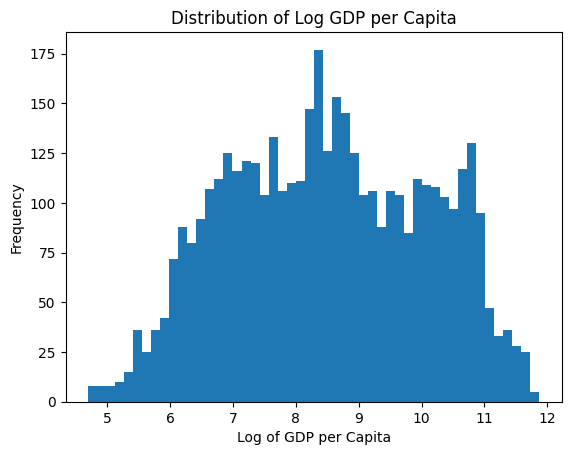

In [30]:
df["ln_GDPpc"] = np.log(df["GDPperCapita"])
df["ln_Emissions_pc"] = np.log(df["GHGperCapita"])

plt.hist(df["ln_GDPpc"].dropna(), bins=50)
plt.xlabel("Log of GDP per Capita")
plt.ylabel("Frequency")
plt.title("Distribution of Log GDP per Capita")
plt.show()


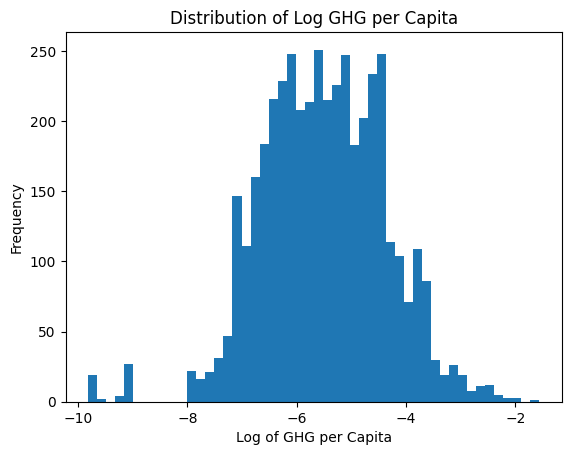

In [32]:
plt.hist(df["ln_Emissions_pc"].dropna(), bins=50)
plt.xlabel("Log of GHG per Capita")
plt.ylabel("Frequency")
plt.title("Distribution of Log GHG per Capita")
plt.show()

## After log transformation, the skewness is removed and it is looks more like a normal distribution.

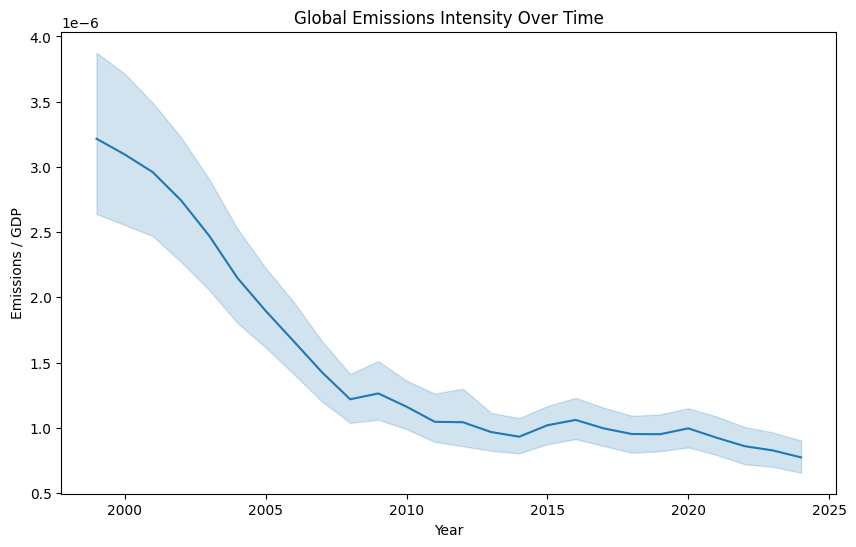

In [17]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="Year",
    y="Emission_Intensity"
)

plt.title("Global Emissions Intensity Over Time")
plt.ylabel("Emissions / GDP")
plt.show()

## Emissions Distribution by Income Level

In [18]:
df["income_group"] = pd.qcut(df["GDPperCapita"], 4,
                             labels=["Low", "Lower-Middle", "Upper-Middle", "High"])

In [19]:
df.head()

,Country_x,ISO3,Year,GHG_Emissions,GDP_USD,Country_y,Unit,Population,GDPperCapita,GHGperCapita,Emission_Intensity,ln_GDPpc,ln_Emissions_pc,income_group
0,Afghanistan,AFG,1999,16508.477865,NaN,Afghanistan,Persons,19887785.0,NaN,0.000830,NaN,NaN,-7.093987,NaN
1,Afghanistan,AFG,2000,14364.940472,3.521418e+09,Afghanistan,Persons,20130327.0,174.930991,0.000714,0.000004,5.164392,-7.245192,Low
2,Afghanistan,AFG,2001,12628.446200,2.813572e+09,Afghanistan,Persons,20284307.0,138.706822,0.000623,0.000004,4.932363,-7.381651,Low
3,Afghanistan,AFG,2002,15228.571950,3.825701e+09,Afghanistan,Persons,21378117.0,178.954088,0.000712,0.000004,5.187129,-7.246950,Low
4,Afghanistan,AFG,2003,15857.564957,4.520947e+09,Afghanistan,Persons,22733049.0,198.871116,0.000698,0.000004,5.292657,-7.267928,Low


C:\Users\indra\AppData\Local\Temp\ipykernel_21784\435102889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


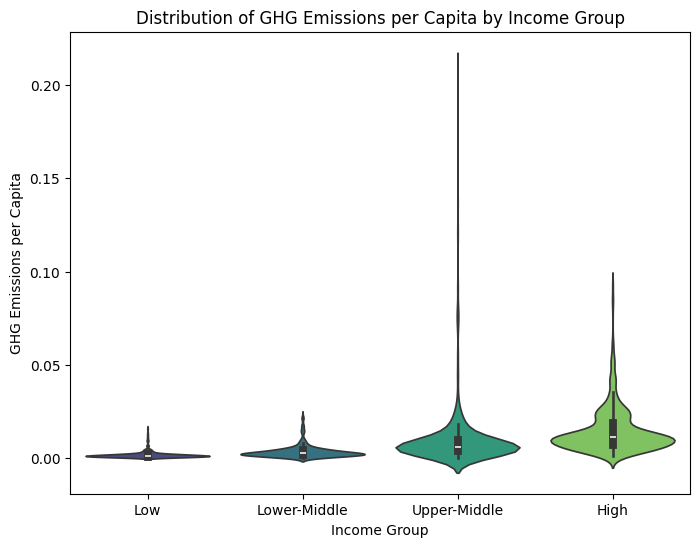

In [21]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="income_group",
    y="GHGperCapita",
    palette="viridis"
)

plt.title("Distribution of GHG Emissions per Capita by Income Group")
plt.xlabel("Income Group")
plt.ylabel("GHG Emissions per Capita")

plt.show()

C:\Users\indra\AppData\Local\Temp\ipykernel_21784\2503125457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


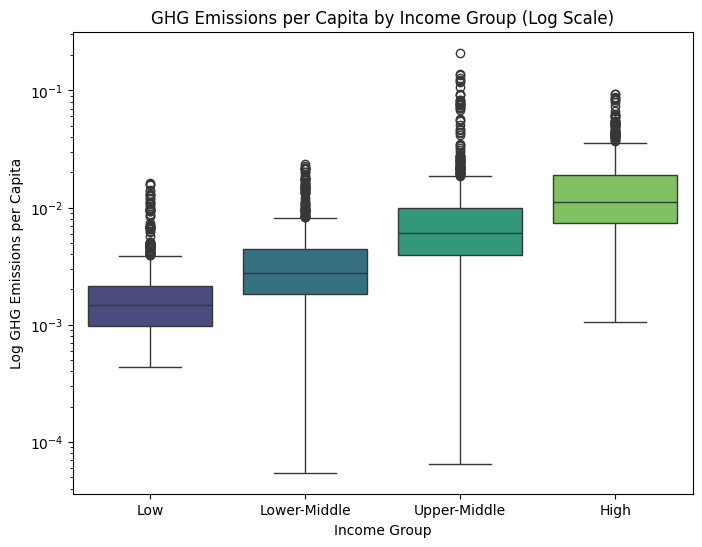

In [22]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="income_group",
    y="GHGperCapita",
    palette="viridis"
)

plt.yscale("log")

plt.title("GHG Emissions per Capita by Income Group (Log Scale)")
plt.xlabel("Income Group")
plt.ylabel("Log GHG Emissions per Capita")

plt.show()

In [23]:
print(df[(df['GHGperCapita'] > 0.20) & (df["ISO3"].notnull())])

     Country_x ISO3  Year  GHG_Emissions       GDP_USD Country_y     Unit  \
3055     Palau  PLW  2012    3720.993394  2.156169e+08     Palau  Persons   

      Population  GDPperCapita  GHGperCapita  Emission_Intensity  ln_GDPpc  \
3055     17765.0  12137.173224      0.209456            0.000017  9.404028   

      ln_Emissions_pc  income_group  
3055         -1.56324  Upper-Middle  


## Top Emitters Over Time

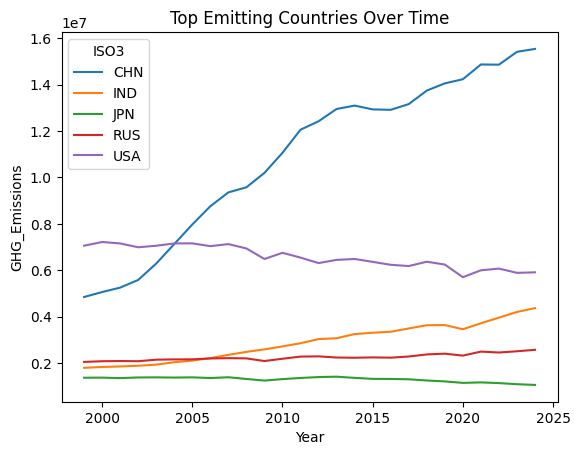

In [35]:
top_countries = df.groupby("ISO3")["GHG_Emissions"].sum().nlargest(5).index

sns.lineplot(
    data=df[df["ISO3"].isin(top_countries)],
    x="Year",
    y="GHG_Emissions",
    hue="ISO3"
)

plt.title("Top Emitting Countries Over Time")
plt.show()

I will be choosing the Top 30 emitting countries by the latest year (2024)

In [25]:
latest_year = df['Year'].max()
print(f"Latest year: {latest_year}")


Latest year: 2024


In [40]:
# Rank countries by total GHG in the latest year
latest = df[df['Year'] == latest_year].sort_values('GHG_Emissions', ascending=False)
top30_isos = latest.head(30)['ISO3'].tolist()
top10_isos = latest.head(10)['ISO3'].tolist()

C:\Users\indra\AppData\Local\Temp\ipykernel_21784\393670424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Top 10 GHG Emitting Countries in 2024')

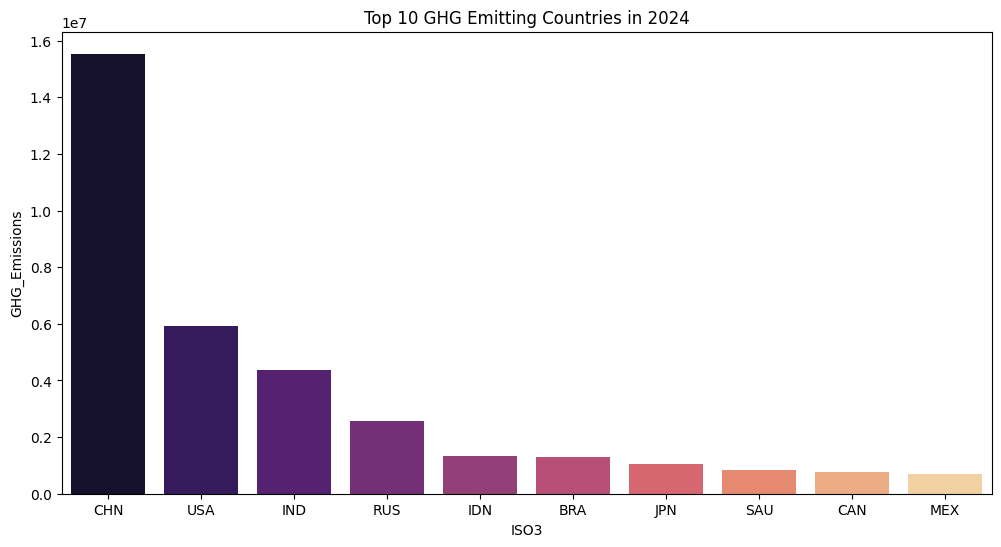

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=latest[latest['ISO3'].isin(top10_isos)],
    x='ISO3',
    y='GHG_Emissions',
    palette='magma'
)
plt.title(f"Top 10 GHG Emitting Countries in {latest_year}")

Text(0.5, 1.0, 'Top 10 GHG/Capita Emitting Countries in 2024')

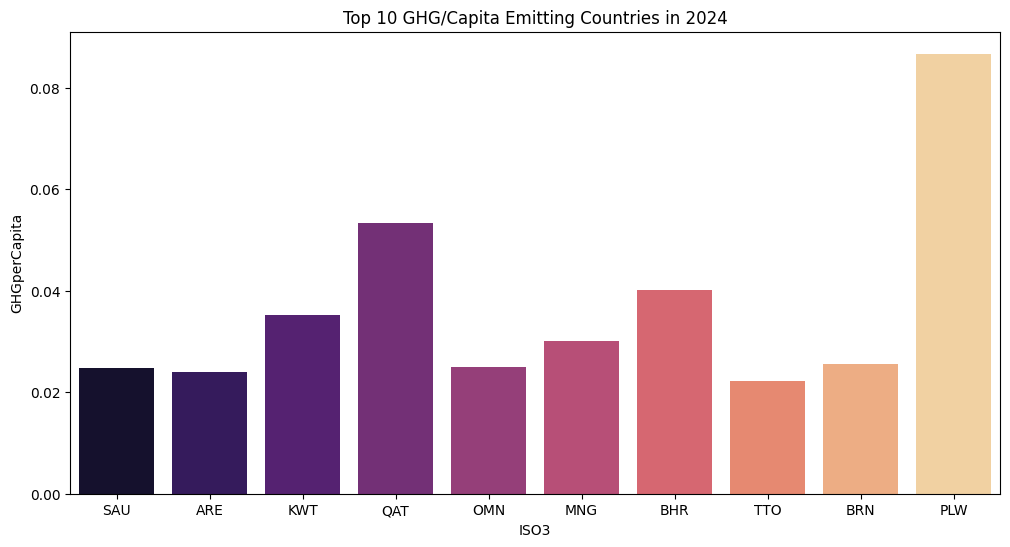

In [ ]:
latest_ghg_per_capita = latest.sort_values('GHGperCapita', ascending=False)
top10_ghg_per_capita_isos = latest_ghg_per_capita.head(10)['ISO3'].tolist()
plt.figure(figsize=(12,6))
sns.barplot(
    data=latest[latest['ISO3'].isin(top10_ghg_per_capita_isos)],
    x='ISO3',
    y='GHGperCapita',
    palette='magma',
    hue='ISO3'
)
plt.title(f"Top 10 GHG/Capita Emitting Countries in {latest_year}")

In [38]:
print(f"\\nTop 30 emitters ({latest_year}):")
print(latest[['ISO3', 'Country_x', 'GHG_Emissions', 'GDPperCapita','GHGperCapita']].head(30).to_string(index=False))

\nTop 30 emitters (2024):
ISO3            Country_x  GHG_Emissions  GDPperCapita  GHGperCapita
 CHN                China   1.553612e+07  13206.173585      0.010946
 USA        United States   5.912618e+06  83233.192072      0.017117
 IND                India   4.371169e+06   2694.737809      0.003013
 RUS   Russian Federation   2.575655e+06  15010.561091      0.017785
 IDN            Indonesia   1.323778e+06   4925.430488      0.004670
 BRA               Brazil   1.299180e+06  10310.548878      0.006128
 JPN                Japan   1.063336e+06  32545.442851      0.008592
 SAU         Saudi Arabia   8.388766e+05  36504.825958      0.024700
 CAN               Canada   7.680589e+05  56454.444950      0.019326
 MEX               Mexico   6.867794e+05  14185.781225      0.005248
 DEU              Germany   6.743583e+05  55416.538544      0.007976
 AUS            Australia   5.914540e+05  65773.554751      0.022141
 VNM             Viet Nam   5.842576e+05   4717.290287      0.005785
 ZAF    

In [28]:
# Filter the full panel to only these 30 countries
df_top30 = df[df['ISO3'].isin(top30_isos)].copy()

print(f"\nFiltered dataset: {df_top30.shape[0]} rows, {df_top30['ISO3'].nunique()} countries")
print(f"Year range: {df_top30['Year'].min()} - {df_top30['Year'].max()}")



Filtered dataset: 780 rows, 30 countries
Year range: 1999 - 2024


### After filtering the dataset for the top 30 emitting countries from 1999-2024, the dataset has 780 rows. It is also worth noting the diference in total emissions of the country and the emissions per capita of these countries.

In [29]:
# Save
df_top30.to_csv('C:\\Users\\indra\\Desktop\\GitHub\\AI Appliction\\emissions_top30.csv', index=False)